In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

ModuleNotFoundError: No module named 'tensorflow.python'

In [29]:
url = "https://air-quality-api.open-meteo.com/v1/air-quality?latitude=10.8231&longitude=106.6297&hourly=pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,ozone,us_aqi&start_date=2024-01-01&end_date=2024-12-31"
response = requests.get(url)
data = response.json()
df = pd.DataFrame(data["hourly"])


features = ["pm2_5", "pm10", "carbon_monoxide", "nitrogen_dioxide", "ozone"]
target = "us_aqi"

WINDOW_SIZE = 6

def create_windows(df, window_size):
    x,y = [], []
    for i in range(len(df)-window_size):
        x.append(df[features].iloc[i: i + window_size].values.flatten())
        y.append(df[target].iloc[i + window_size])
    return np.array(x), np.array(y)

x,y = create_windows(df, WINDOW_SIZE)



Split train/test (80/20) - without shuffle to keep the contination of time

In [30]:
split = int(0.8*len(x))
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]

# Format the data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Input shape: {x_train_scaled.shape}")

Input shape: (7022, 30)


In [6]:
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import regularizers

# --- Build up Model MLP (for RA6M5)

input_shape=WINDOW_SIZE * len(features)

model = Sequential([
    Input(shape=(input_shape,)),
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dropout(0.2),
    Dense(8, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    Dense(1) #Predict AQI values continously
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])

In [7]:
# Training model (NOTE: SHOULD TRAIN ON KAGGLE NOTEBOOK)
from tensorflow.keras.callbacks import EarlyStopping

# Early stop for avoid wasting GPU
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True) 

history = model.fit(
    x_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1 # Nên để 1 để theo dõi tiến độ lúc đầu
)

Epoch 1/100


I0000 00:00:1772867368.137657     128 service.cc:152] XLA service 0x7a3a70009810 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772867368.137695     128 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772867368.137700     128 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772867368.398633     128 cuda_dnn.cc:529] Loaded cuDNN version 91002


 79/198 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4993.4888 - mae: 68.4088

I0000 00:00:1772867369.610353     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 4923.4102 - mae: 67.9587 - val_loss: 6173.2212 - val_mae: 76.5241
Epoch 2/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4321.1382 - mae: 63.7600 - val_loss: 3920.5540 - val_mae: 58.9333
Epoch 3/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2841.8335 - mae: 49.9739 - val_loss: 2394.7559 - val_mae: 42.0270
Epoch 4/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1694.0636 - mae: 34.4947 - val_loss: 1976.7754 - val_mae: 37.8181
Epoch 5/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1356.8336 - mae: 30.1589 - val_loss: 1723.3870 - val_mae: 35.4955
Epoch 6/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1194.2251 - mae: 28.1829 - val_loss: 1509.9076 - val_mae: 32.8543
Epoch 7/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1031.2655 - mae: 26.1205 - val_loss: 1305.6918 - val_mae: 30.0174
Epoch 8/100
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 913.7246 - mae: 24.5710 - val_loss: 1140.5310 - val_mae: 27.2


**Visualizing History**

*Sau khi chạy xong đoạn code của bạn, hãy thêm đoạn này để xem đường cong của Loss và MAE. Nếu đường màu cam (Validation) bắt đầu tăng lên trong khi đường màu xanh (Train) vẫn giảm, nghĩa là mô hình đang học vẹt.*

In [3]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (MSE)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

NameError: name 'history' is not defined


**Khi đường Train Loss và Validation Loss cùng giảm dần đến một ngưỡng nhất định rồi bắt đầu đi ngang (flatten out), đây là một dấu hiệu cực kỳ tích cực.Trong kỹ thuật học máy, hiện tượng này được gọi là Sự hội tụ (Convergence)**


In [2]:
from sklearn.metrics import mean_absolute_error, r2_score

# ---Review & Generate output
mae = model.evaluate(x_test_scaled, y_test, verbose=0)[1]
y_pred = model.predict(x_test_scaled)
rsme = np.sqrt(mean_absolute_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Model MAE: {mae:.2f}")
print(f"RSME: {rsme: .2f}")
print(f"R2 Score: {r2:.2f}")

ModuleNotFoundError: No module named 'sklearn'

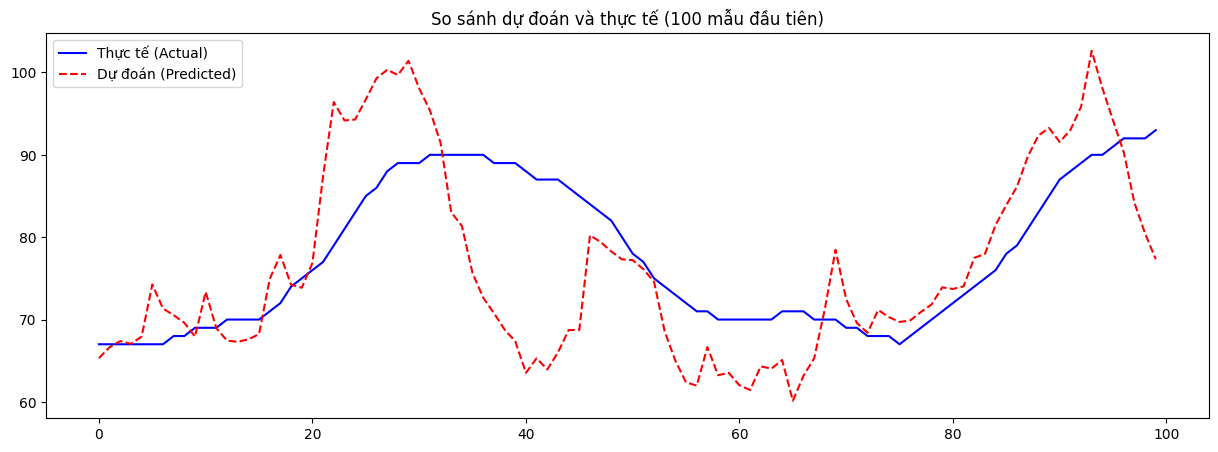

In [12]:
plt.figure(figsize=(15, 5))
plt.plot(y_test[:100], label='Thực tế (Actual)', color='blue')
plt.plot(y_pred[:100], label='Dự đoán (Predicted)', color='red', linestyle='--')
plt.title('So sánh dự đoán và thực tế (100 mẫu đầu tiên)')
plt.legend()
plt.show()

In [13]:
# IMPORTANT: SAVE THIS NUMBERS FOR APPLY WITH C LANGUAGE ON KIT
print(f"Mean (6 hours (marks) x 5 features): \n{scaler.mean_}")
print(f"Scale (6 hours (marks) x 5 features): \n{scaler.scale_}")



Mean (6 hours (marks) x 5 features): 
[ 20.97727143  31.73751068 389.16590715  24.95972657  54.51523782
  20.97530618  31.73463401 389.15949872  24.9628311   54.51395614
  20.9731558   31.73141555 389.16063799  24.96602108  54.50882939
  20.97100541  31.72811165 389.16904016  24.96925377  54.49886072
  20.96852749  31.72429507 389.18128738  24.9726004   54.48490459
  20.9658217   31.72009399 389.19624039  24.97628881  54.46838508]
Scale (6 hours (marks) x 5 features): 
[  9.90920511  14.23726182 184.97568013  14.42531652  38.06490557
   9.90761367  14.2351474  184.96693777  14.42827298  38.06635389
   9.90562193  14.23235104 184.96829183  14.43135369  38.07086691
   9.90371617  14.229572   184.97566574  14.43444068  38.07571175
   9.90168176  14.22657471 184.98253985  14.43747274  38.07735815
   9.89967776  14.2235246  184.98773835  14.4404297   38.07539568]


Mỗi lần chạy suy luận, kit sẽ cần một mảng đầu vào gồm 30 số (6 mốc thời gian x 5 chỉ số )
Dữ liệu này sẽ được lưu trong một Circular Buffer (Bộ đệm vòng) trên kit. Cứ mỗi tiếng trôi qua, kit đầy dữ liệu mới vào và đẩy dữ liệu cũ ra.

Để kiểm tra lại code, kiểm tra khả năng dự đoán của model với dữ liệu lạ ngẫu nhiên như sau:

In [18]:
# Tạo dữ liệu ngẫu nhiên theo phân phối chuẩn (Mean=0, Std=1) 
# Đây mới là dạng dữ liệu mà Model của bạn đang mong đợi
sample_input_scaled = np.random.normal(0, 1, size=(1, 30))

# Predict
prediction = model.predict(sample_input_scaled)

print(f"Input data (scaled): {sample_input_scaled[0][:5]} ...")
print(f"Predict AQI for the next hour: {prediction[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Input data (scaled): [ 0.11627719 -1.97143487  0.25253391 -0.98483778 -0.21811519] ...
Predict AQI for the next hour: 61.89


In [33]:
# Lấy mẫu thực tế từ tập test
sample_from_test = x_test_scaled[0:1] 
prediction = model.predict(sample_from_test)

# Lấy giá trị thực tế tương ứng
actual_value = y_test[0]

print(f"Giá trị dự đoán (Predicted): {prediction[0][0]:.2f}")
print(f"Giá trị thực tế (Actual): {actual_value:.2f}")
print(f"Sai số (Error): {abs(prediction[0][0] - actual_value):.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Giá trị dự đoán (Predicted): 65.32
Giá trị thực tế (Actual): 67.00
Sai số (Error): 1.68


In [34]:
# Save file on Kaggle
model.save("AQI_model.h5")

In [37]:
import tensorflow as tf

# Chuyển đổi trực tiếp từ đối tượng model trong bộ nhớ
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT] # Tối ưu hóa dung lượng cho MCU
tflite_model = converter.convert()

# Lưu thành file .tflite
with open('aqi_model.tflite', 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmpw8gs66ys/assets


INFO:tensorflow:Assets written to: /tmp/tmpw8gs66ys/assets


Saved artifact at '/tmp/tmpw8gs66ys'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134394623716304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134394623715152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134394623718032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134394623718608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134394623717264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134394623716496: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1772870363.193251      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1772870363.193276      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
